In [ ]:
import micropip

await micropip.install(
    "https://parsod.github.io/jlitedemos/wheels/iondistribution-0.1.0-py3-none-any.whl"
)

---------------------------
Welcome to iondistribution2!
(c) Kristofer Modig, 2015.
    Updated with LJ 2020.
    Python rewrite for Jupyter.
---------------------------
Some data for your system:
  Concentrations:
    Total ion concentration is 124.541 mM
    An-ion concentration is 83.0275 mM
    Cat-ion concentration is 41.5138 mM
    Ionic strength is 62.2706 mM
    Debye length is 7.13663 A
  Simulation box:
    Distance between planes is 80 A
    Box area along plane is 10000 A^2
    Box side is 100 A
    Box volume is 800000 A^3
  Lennard Jones Parameters (energy reduced by rel perm):
         i-j   sig (A)  eps (J/mol)
       an-an     4.860        0.628
     cat-cat     2.730        1.339
      an-cat     3.795        0.917
Charged boundary. Periodic boundary y and z directions.


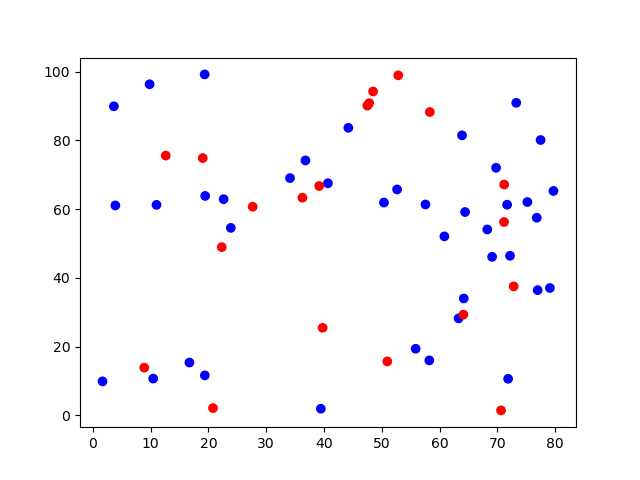

0.03301876633175378

In [1]:
%matplotlib widget

from iondistribution import IonDistributionMC, SimulationConfig

cfg = SimulationConfig(
    surface_distance = 80,
    box_area = 10000.0,
    n_anion = 40,
    n_cation = 20,
    charge_dens_left = 20,
    charge_dens_right = 0,
    temperature = 30
)

sim = IonDistributionMC(cfg)
sim.print_system_info()
sim.initialize(show=True)


Running 100000 steps of equilibration...


'Simulation done.'

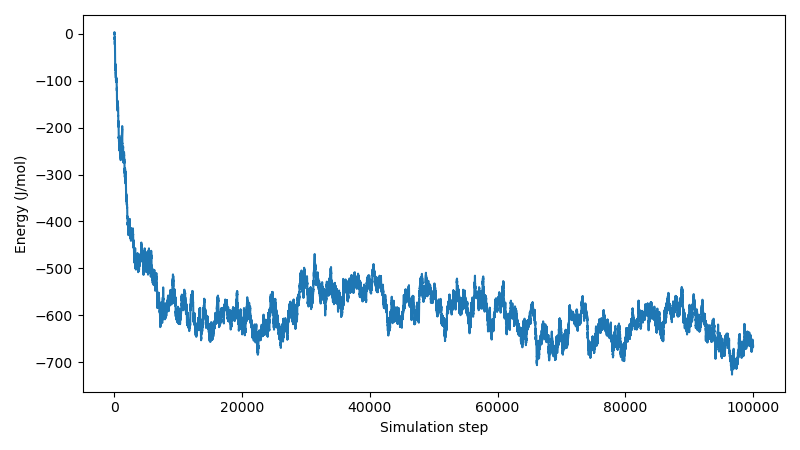

In [2]:
# Ekvilibrering
sim.run_segment(nmc=100000,production=False,plot_every=100)
sim.plot_energy()

Running 50000 steps of production


'Simulation done.'

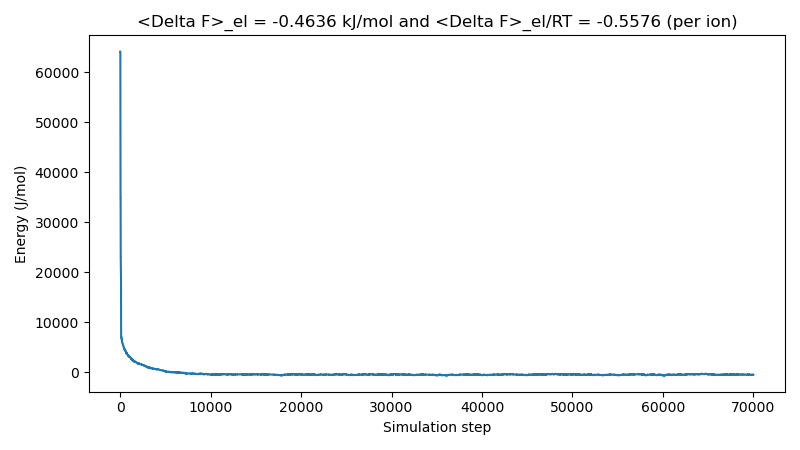

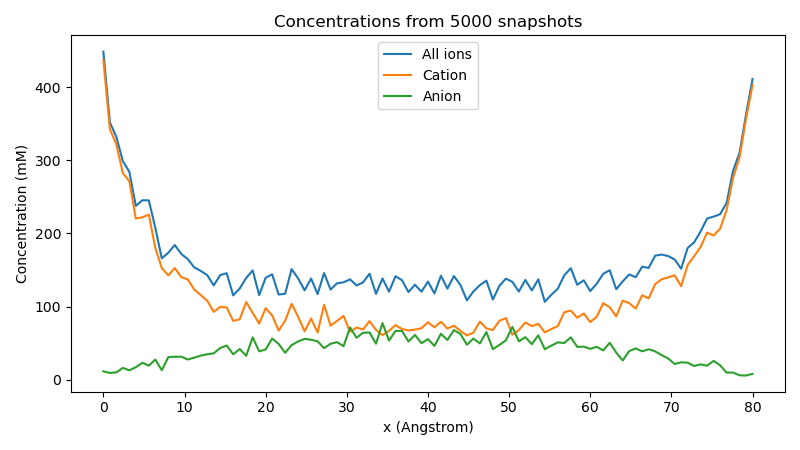

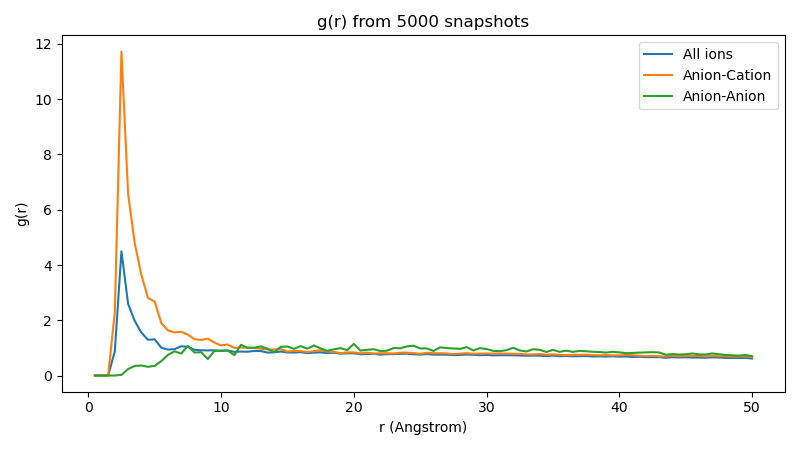

Electrostatic free energy after 50000 steps:
  Per ion:
    <Delta F> = -0.4636 kJ/mol
    <Delta F>/(RT) = -0.5576
  For all 20+60 = 80 ions:
    <Delta F> = -37.09 kJ/mol
    <Delta F>/(RT) = -44.6


In [15]:
# Produktionskörning
sim.run_segment(nmc=50000,production=True,plot_every=1000)
sim.plot_energy()
sim.plot_profiles()
sim.plot_gr()
sim.print_free_energy()

In [18]:
print(sim.BOXP.x)
print(sim.BOXP.pCat)


[ 0.   0.8  1.6  2.4  3.2  4.   4.8  5.6  6.4  7.2  8.   8.8  9.6 10.4
 11.2 12.  12.8 13.6 14.4 15.2 16.  16.8 17.6 18.4 19.2 20.  20.8 21.6
 22.4 23.2 24.  24.8 25.6 26.4 27.2 28.  28.8 29.6 30.4 31.2 32.  32.8
 33.6 34.4 35.2 36.  36.8 37.6 38.4 39.2 40.  40.8 41.6 42.4 43.2 44.
 44.8 45.6 46.4 47.2 48.  48.8 49.6 50.4 51.2 52.  52.8 53.6 54.4 55.2
 56.  56.8 57.6 58.4 59.2 60.  60.8 61.6 62.4 63.2 64.  64.8 65.6 66.4
 67.2 68.  68.8 69.6 70.4 71.2 72.  72.8 73.6 74.4 75.2 76.  76.8 77.6
 78.4 79.2 80. ]
[10527.  8254.  7748.  6807.  6537.  5311.  5349.  5442.  4340.  3682.
  3437.  3679.  3381.  3305.  2972.  2789.  2603.  2237.  2401.  2382.
  1939.  1992.  2561.  2204.  1851.  2359.  2116.  1624.  1944.  2501.
  2076.  1597.  2015.  1556.  2472.  1783.  1939.  2104.  1581.  1720.
  1659.  1933.  1642.  1469.  1611.  1800.  1672.  1627.  1653.  1697.
  1895.  1728.  1911.  1689.  1781.  1612.  1462.  1552.  1918.  1692.
  1635.  1943.  2033.  1483.  1638.  1886.  1769.  1843.  156

In [42]:
import numpy as np
from matplotlib import pyplot as plt
#Tvec=np.array([50,100,150,200,250,300])
Tvec=[30,300]
cAlls=[]
cCats=[]
cAns=[]
for T in Tvec:
    cfg = SimulationConfig(
        surface_distance = 100,
        box_area = 10000.0,
        n_anion = 20,
        n_cation = 60,
        charge_dens_left = -20,
        charge_dens_right = -20,
        temperature = T
    )
    
    sim = IonDistributionMC(cfg)
    sim.print_system_info()
    sim.initialize(show=False)
    sim.run_segment(nmc=40000,production=False)
    sim.run_segment(nmc=200000,production=True)
    cAll, cCat, cAn = sim.normalized_profiles()
    cAlls.append(cAll)
    cCats.append(cCat)
    cAns.append(cAn)


---------------------------
Welcome to iondistribution2!
(c) Kristofer Modig, 2015.
    Updated with LJ 2020.
    Python rewrite for Jupyter.
---------------------------
Some data for your system:
  Concentrations:
    Total ion concentration is 132.844 mM
    An-ion concentration is 33.211 mM
    Cat-ion concentration is 99.633 mM
    Ionic strength is 66.422 mM
    Debye length is 6.91001 A
  Simulation box:
    Distance between planes is 100 A
    Box area along plane is 10000 A^2
    Box side is 100 A
    Box volume is 1e+06 A^3
  Lennard Jones Parameters (energy reduced by rel perm):
         i-j   sig (A)  eps (J/mol)
       an-an     4.860        0.628
     cat-cat     2.730        1.339
      an-cat     3.795        0.917
Charged boundary. Periodic boundary y and z directions.
Running 40000 steps of equilibration...
None


'Simulation done.'

Running 200000 steps of production
None


'Simulation done.'

---------------------------
Welcome to iondistribution2!
(c) Kristofer Modig, 2015.
    Updated with LJ 2020.
    Python rewrite for Jupyter.
---------------------------
Some data for your system:
  Concentrations:
    Total ion concentration is 132.844 mM
    An-ion concentration is 33.211 mM
    Cat-ion concentration is 99.633 mM
    Ionic strength is 66.422 mM
    Debye length is 11.7835 A
  Simulation box:
    Distance between planes is 100 A
    Box area along plane is 10000 A^2
    Box side is 100 A
    Box volume is 1e+06 A^3
  Lennard Jones Parameters (energy reduced by rel perm):
         i-j   sig (A)  eps (J/mol)
       an-an     4.860        2.161
     cat-cat     2.730        4.604
      an-cat     3.795        3.154
Charged boundary. Periodic boundary y and z directions.
Running 40000 steps of equilibration...
None


'Simulation done.'

Running 200000 steps of production
None


'Simulation done.'

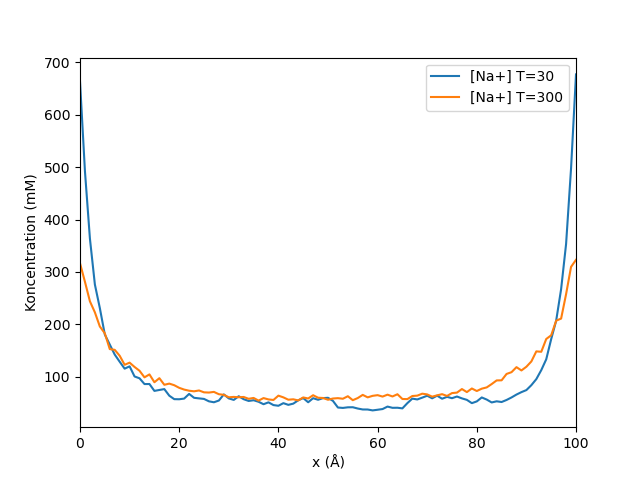

In [49]:
#saved=cCats,cAns,cAlls
plt.close('all')
for i in [0,1]:
    plt.plot(sim.BOXP.x,cCats[i],label='[Na+] T=%.0f'%Tvec[i])
plt.legend()
plt.xlim((0,100))
plt.xlabel('x (Å)')
plt.ylabel('Koncentration (mM)')
plt.show()

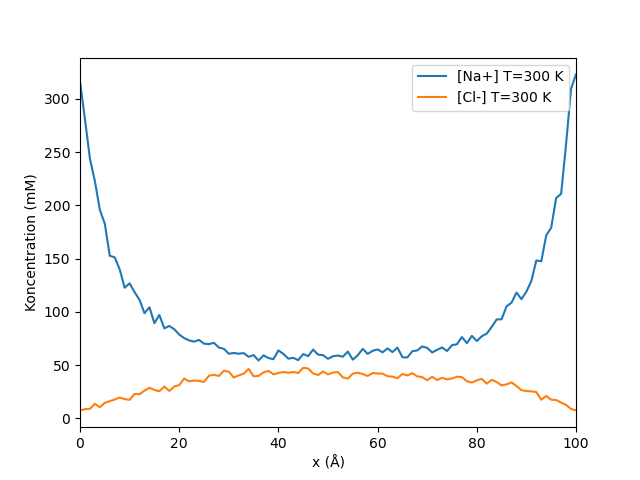

In [57]:
plt.close('all')
plt.plot(sim.BOXP.x,cCats[1],label='[Na+] T=%.0f K'%Tvec[1])
plt.plot(sim.BOXP.x,cAns[1],label='[Cl-] T=%.0f K'%Tvec[1])
plt.legend()
plt.xlim((0,100))
plt.xlabel('x (Å)')
plt.ylabel('Koncentration (mM)')
plt.show()


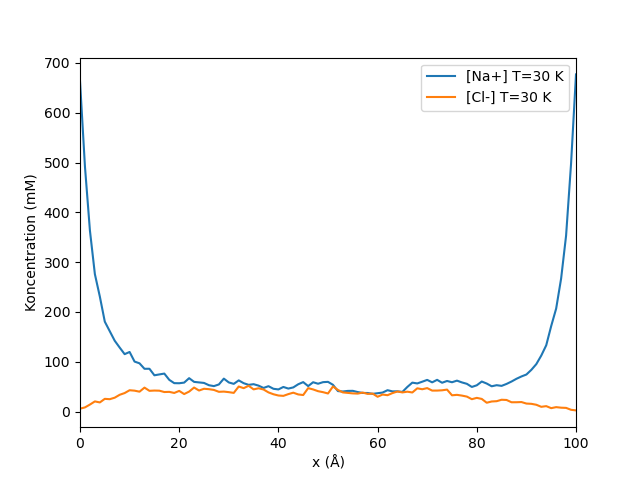

In [56]:
plt.close('all')
plt.plot(sim.BOXP.x,cCats[0],label='[Na+] T=%.0f K'%Tvec[0])
plt.plot(sim.BOXP.x,cAns[0],label='[Cl-] T=%.0f K'%Tvec[0])
plt.legend()
plt.xlim((0,100))
plt.xlabel('x (Å)')
plt.ylabel('Koncentration (mM)')
plt.show()

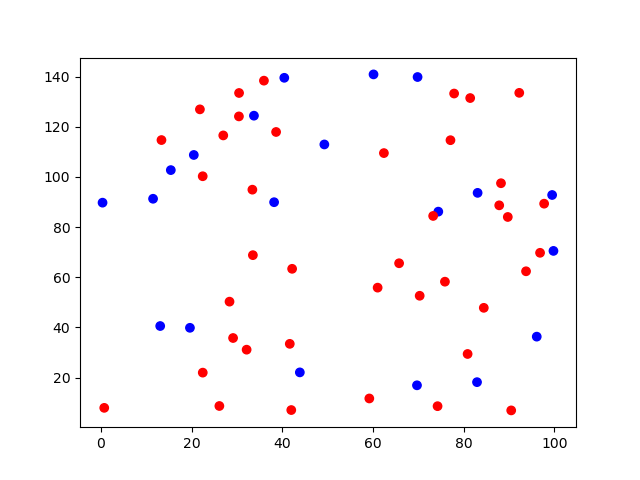

In [7]:
import numpy as np
import time
import matplotlib.pyplot as plt
%matplotlib widget
from IPython.display import display
import asyncio

#plt.plot(sim.IONS.Pos[:sim.IONS.nAnIon,0],sim.IONS.Pos[:sim.IONS.nAnIon,1],'bo')
#plt.plot(sim.IONS.Pos[sim.IONS.nAnIon:,0],sim.IONS.Pos[sim.IONS.nAnIon:,1],'ro')
plt.ion()
fig, ax = plt.subplots()

points=ax.scatter(sim.IONS.Pos[:,0],sim.IONS.Pos[:,1],c=sim.IONS.Charge,cmap='bwr')
#display(fig.canvas)

In [9]:
await asyncio.sleep(1)
points.set_offsets(np.c_[sim.IONS.Pos[:,0],sim.IONS.Pos[:,2]])
fig.canvas.draw()
await asyncio.sleep(1)
points.set_offsets(np.c_[sim.IONS.Pos[:,0],sim.IONS.Pos[:,1]])
fig.canvas.draw()
await asyncio.sleep(1)
points.set_offsets(np.c_[sim.IONS.Pos[:,0],sim.IONS.Pos[:,2]])
fig.canvas.draw()
await asyncio.sleep(1)
points.set_offsets(np.c_[sim.IONS.Pos[:,0],sim.IONS.Pos[:,1]])
fig.canvas.draw()
await asyncio.sleep(1)
points.set_offsets(np.c_[sim.IONS.Pos[:,0],sim.IONS.Pos[:,2]])
fig.canvas.draw()
#fig.canvas.draw_idle()
#plt.show()
#sim.IONS.Charge
#sim.IONS.Pos[:,0]